# Hotel Booking Demand - Exploratory Data Analysis

## Dataset Description

This dataset contains booking information for two types of hotels:
- City Hotel
- Resort Hotel

It includes booking dates, customer demographics, reservation details, cancellations, special requests, and other attributes.

Number of Rows: ~119,000
Number of Columns: 32

Target Variable:
- is_canceled (0 = Not Canceled, 1 = Canceled)

# Column Description

| Column | Description |
|---------|-------------|
| **hotel** | Type of hotel (`City Hotel` or `Resort Hotel`). |
| **is_canceled** | Whether the booking was canceled (1 = Yes, 0 = No). This is the target variable in many ML projects. |
| **lead_time** | Number of days between the booking date and the arrival date. |
| **arrival_date_year** | Year of arrival. |
| **arrival_date_month** | Month of arrival. |
| **arrival_date_week_number** | Week number of the year when the guest arrives. |
| **arrival_date_day_of_month** | Day of the month when the guest arrives. |
| **stays_in_weekend_nights** | Number of weekend nights (Saturday or Sunday) booked. |
| **stays_in_week_nights** | Number of weekday nights (Monday to Friday) booked. |
| **adults** | Number of adults included in the booking. |
| **children** | Number of children included in the booking. May contain missing values. |
| **babies** | Number of babies included in the booking. |
| **meal** | Type of meal booked (e.g., BB = Bed & Breakfast, HB = Half Board, FB = Full Board, SC = Self Catering). |
| **country** | Country of origin of the customer (ISO country code). |
| **market_segment** | Market segment through which the booking was made (e.g., Online TA, Direct, Corporate). |
| **distribution_channel** | Booking distribution channel (e.g., Direct, Travel Agent, GDS). |
| **is_repeated_guest** | Whether the customer has stayed at the hotel before (1 = Yes, 0 = No). |
| **previous_cancellations** | Number of previous bookings canceled by the customer before this booking. |
| **previous_bookings_not_canceled** | Number of previous bookings completed without cancellation. |
| **reserved_room_type** | Room type originally reserved by the customer. |
| **assigned_room_type** | Room type actually assigned at check-in. |
| **booking_changes** | Number of changes made to the booking before arrival. |
| **deposit_type** | Type of deposit made (`No Deposit`, `Refundable`, `Non Refund`). |
| **agent** | ID of the travel agent who made the booking. May contain missing values. |
| **company** | ID of the company responsible for the booking or payment. May contain many missing values. |
| **days_in_waiting_list** | Number of days the booking was on the waiting list before confirmation. |
| **customer_type** | Type of customer (e.g., Transient, Contract, Group, Transient-Party). |
| **adr** | Average Daily Rate (average room rental price per night). |
| **required_car_parking_spaces** | Number of parking spaces requested by the customer. |
| **total_of_special_requests** | Number of special requests made by the customer (e.g., high floor, twin bed). |
| **reservation_status** | Final reservation status (`Check-Out`, `Canceled`, `No-Show`). |
| **reservation_status_date** | Date when the reservation status was last updated. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df= pd.read_csv('hotel_bookings.csv')

In [18]:
pd.set_option('display.max_columns', None)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [20]:
df.shape

(119390, 32)

In [21]:
df.duplicated().sum()

31994

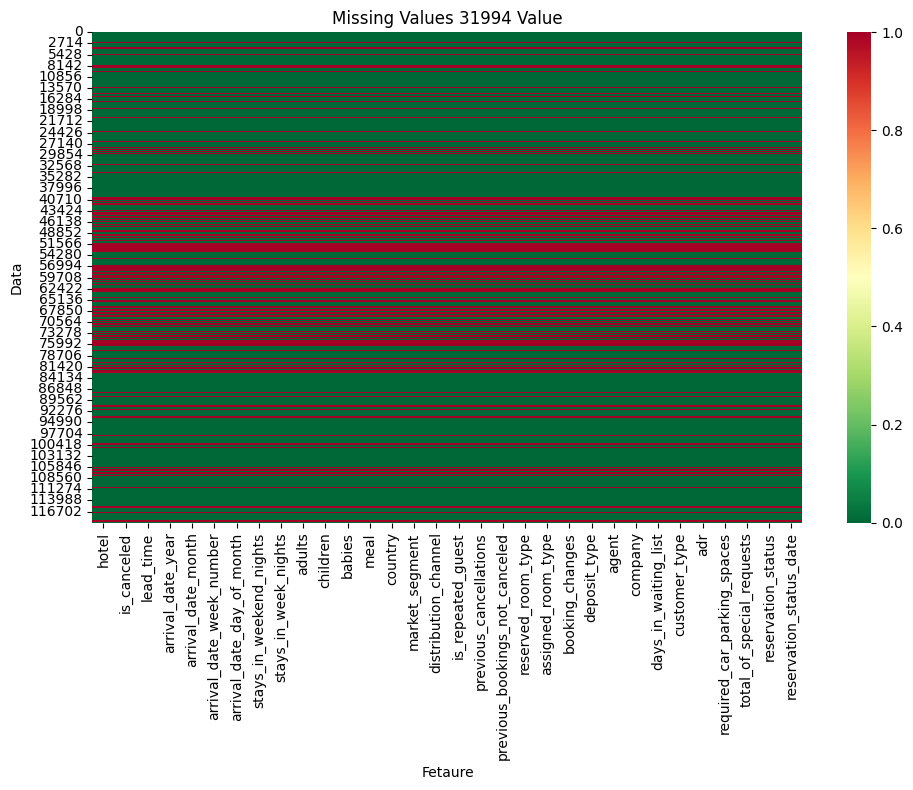

In [30]:
plt.figure(figsize=(10,8))
duplicate_mtx=np.tile(df.duplicated().values.reshape(-1,1),df.shape[1])
sns.heatmap(duplicate_mtx,cbar = True, cmap = 'RdYlGn_r',xticklabels=df.columns)
plt.xlabel("Fetaure")
plt.ylabel("Data")
plt.title(f"Missing Values {df.duplicated().sum()} Value")

plt.tight_layout()
plt.show()

In [31]:
df.drop_duplicates(inplace=True)

In [32]:
df.shape

(87396, 32)

In [33]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


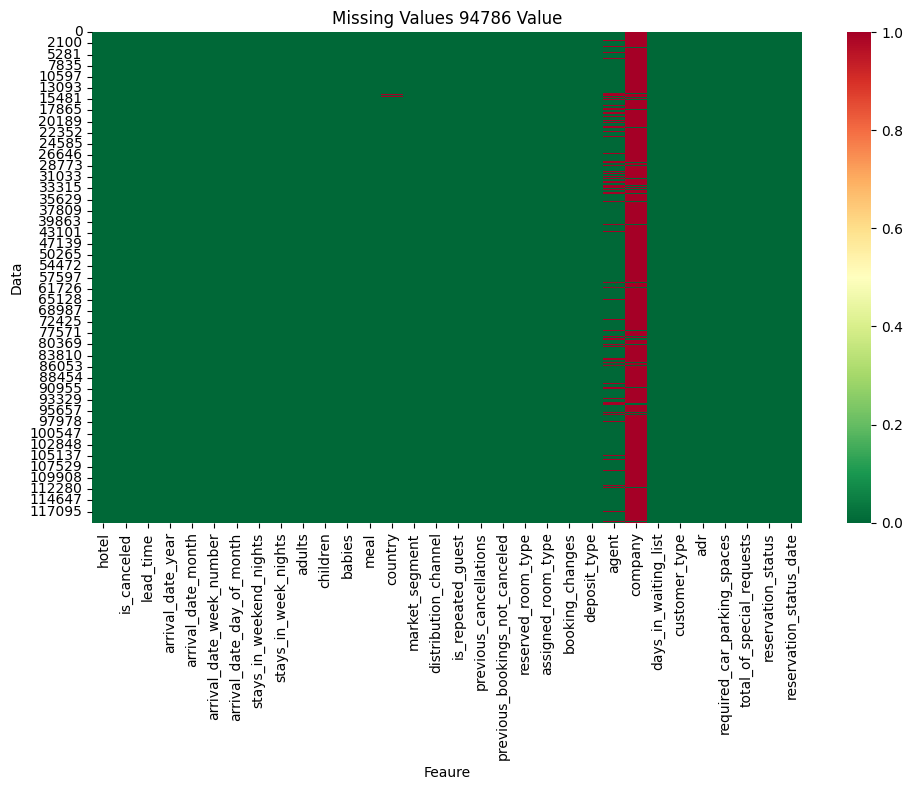

In [34]:
plt.figure(figsize = (10,8))
sns.heatmap(df.isna(),cbar = True, cmap = 'RdYlGn_r')

plt.xlabel("Feaure")
plt.ylabel("Data")
plt.title(f"Missing Values {df.isna().sum().sum()} Value")

plt.tight_layout()
plt.show()

In [35]:
df=df.drop(columns=['company'])

In [36]:
df['country'].nunique()

177

In [37]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87392.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138640,0.010824,0.039075,0.030413,0.183990,0.271603,94.138306,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455881,0.113597,0.193775,0.369145,1.731894,0.727245,113.188172,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000


In [38]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,87396,87396,87396,86944,87396,87396,87396,87396,87396,87396,87396,87396
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14
freq,53428,11257,67978,27453,51618,69141,56552,46313,86251,71986,63371,211


In [39]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

agent                             13.951439
country                            0.517186
children                           0.004577
hotel                              0.000000
previous_cancellations             0.000000
reservation_status                 0.000000
total_of_special_requests          0.000000
required_car_parking_spaces        0.000000
adr                                0.000000
customer_type                      0.000000
days_in_waiting_list               0.000000
deposit_type                       0.000000
booking_changes                    0.000000
assigned_room_type                 0.000000
reserved_room_type                 0.000000
previous_bookings_not_canceled     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
is_canceled                        0.000000
market_segment                     0.000000
meal                               0.000000
babies                             0.000000
adults                          

In [42]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

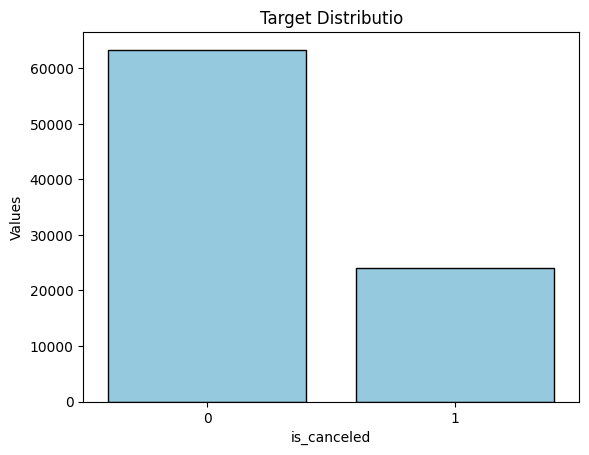

In [48]:
sns.countplot(data=df,x='is_canceled',color='skyblue',edgecolor='black')
plt.xlabel('is_canceled')
plt.ylabel('Values')
plt.title("Target Distributio")
plt.show()